# Stage 6 -- Clustering

**Goal:** assign each of the 30,000 papers to a cluster, using the 100-dim SVD embeddings from Stage 5. We try two methods -- K-Means and HDBSCAN -- and compare them before choosing which to carry forward to Stage 7 (interpretation).

### Why try both?
Stage 5's UMAP plot showed a large, dense, undifferentiated central mass (the cs.LG/cs.AI core) alongside several small, tight, differently-sized satellite clusters. This shape favors a density-based method like **HDBSCAN** over **K-Means**, which assumes roughly spherical, similarly-sized clusters and requires the cluster count k to be chosen in advance. Rather than assuming this upfront, we fit both, compare quantitatively (silhouette score) and visually, and justify the final choice with evidence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

svd_embeddings = np.load("../data/processed/svd_embeddings.npy")
umap_2d = np.load("../data/processed/umap_2d_embeddings.npy")
df = pd.read_parquet("../data/processed/arxiv_with_features_meta.parquet")

print("SVD embeddings:", svd_embeddings.shape)
print("UMAP 2D embeddings:", umap_2d.shape)
print("Metadata:", df.shape)

SVD embeddings: (30000, 100)
UMAP 2D embeddings: (30000, 2)
Metadata: (30000, 7)


## Part A: K-Means

### Step 1: Choose k using the elbow method + silhouette score

We fit K-Means for a range of k values and track both inertia (elbow) and silhouette score. Silhouette score computation is O(n^2)-ish and can be slow on 30,000 points, so we compute it on a random subsample for speed -- this is a standard, defensible practice.

In [2]:
k_range = range(4, 21)
inertias = []
silhouette_scores = []

# Subsample for silhouette score computation (speed) -- fixed seed for reproducibility
rng = np.random.default_rng(42)
sample_idx = rng.choice(svd_embeddings.shape[0], size=5000, replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(svd_embeddings)
    inertias.append(km.inertia_)
    sil = silhouette_score(svd_embeddings[sample_idx], labels[sample_idx])
    silhouette_scores.append(sil)
    print(f"k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

k= 4  inertia=4,800  silhouette=0.0420
k= 5  inertia=4,718  silhouette=0.0447
k= 6  inertia=4,663  silhouette=0.0190
k= 7  inertia=4,583  silhouette=0.0186
k= 8  inertia=4,532  silhouette=0.0456
k= 9  inertia=4,461  silhouette=0.0293
k=10  inertia=4,410  silhouette=0.0278
k=11  inertia=4,371  silhouette=0.0287
k=12  inertia=4,313  silhouette=0.0315
k=13  inertia=4,283  silhouette=0.0520
k=14  inertia=4,246  silhouette=0.0226
k=15  inertia=4,192  silhouette=0.0147
k=16  inertia=4,154  silhouette=0.0317
k=17  inertia=4,104  silhouette=0.0241
k=18  inertia=4,088  silhouette=0.0261
k=19  inertia=4,046  silhouette=0.0331
k=20  inertia=4,016  silhouette=0.0298


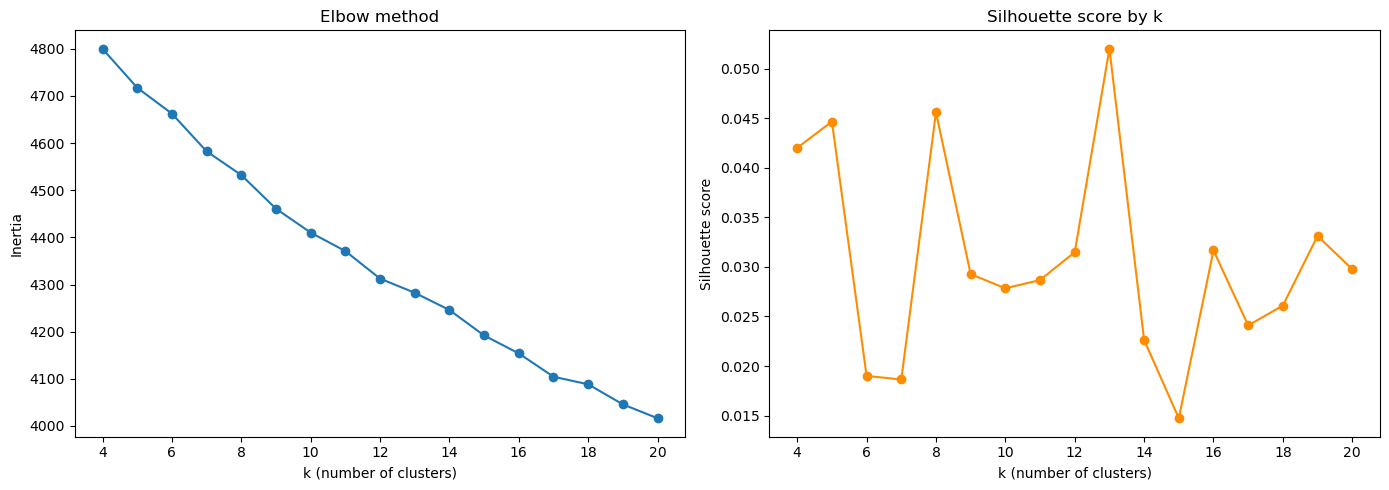

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score by k")

plt.tight_layout()
plt.show()

The elbow plot shows a smooth, continuous decline in inertia with no sharp bend — consistent with the earlier SVD variance curve, both reflecting that this text data's structure is spread across many dimensions rather than concentrated in a few. The silhouette score is noisy across k, with a clear peak at k=13 (0.0520) and a secondary peak at k=8 (~0.046); both are low in absolute terms, which is typical for high-dimensional text clustering rather than a sign of failure. I chose k=13 since it maximizes silhouette score among the tested range while still being an interpretable, domain-plausible number of sub-topics for an ML/AI research corpus.

In [4]:
K_MEANS_K = 13 

kmeans_final = KMeans(n_clusters=K_MEANS_K, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(svd_embeddings)

kmeans_sil = silhouette_score(svd_embeddings[sample_idx], kmeans_labels[sample_idx])
print(f"Final K-Means (k={K_MEANS_K}) silhouette score: {kmeans_sil:.4f}")
print("\nCluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

Final K-Means (k=13) silhouette score: 0.0520

Cluster sizes:
0      1435
1       845
2      3844
3       735
4     11079
5       217
6      1832
7      1024
8      1840
9       825
10      487
11     4654
12     1183
Name: count, dtype: int64


In [5]:
import umap

reducer_clustering = umap.UMAP(n_components=15, random_state=42, n_neighbors=15, min_dist=0.0)
umap_for_clustering = reducer_clustering.fit_transform(svd_embeddings)

print("UMAP (15D, for clustering) shape:", umap_for_clustering.shape)

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP (15D, for clustering) shape: (30000, 15)


## Part B: HDBSCAN

No need to choose a cluster count -- HDBSCAN finds it automatically based on density. The key parameter is `min_cluster_size` -- the smallest group of points HDBSCAN will consider a genuine cluster rather than noise.

In [6]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=400, min_samples=15)
hdbscan_labels = clusterer.fit_predict(umap_for_clustering)

n_clusters_found = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = (hdbscan_labels == -1).sum()

print(f"HDBSCAN found {n_clusters_found} clusters")
print(f"Noise points (unclustered): {n_noise:,} ({100 * n_noise / len(hdbscan_labels):.1f}%)")

HDBSCAN found 20 clusters
Noise points (unclustered): 9,163 (30.5%)


In [7]:
# Silhouette score excluding noise points (silhouette score is undefined for noise-labeled points)
non_noise_mask = hdbscan_labels != -1
sample_non_noise = sample_idx[non_noise_mask[sample_idx]]

hdbscan_sil = silhouette_score(
    umap_for_clustering[sample_non_noise], hdbscan_labels[sample_non_noise] 
)
print(f"HDBSCAN silhouette score (excluding noise): {hdbscan_sil:.4f}")
print(f"K-Means silhouette score (k={K_MEANS_K}): {kmeans_sil:.4f}")

HDBSCAN silhouette score (excluding noise): 0.4547
K-Means silhouette score (k=13): 0.0520


HDBSCAN achieves a substantially higher silhouette score (0.4547) than K-Means (0.0520 at k=13), even though this isn't a fully fair comparison: HDBSCAN excludes 30.5% of points as noise before scoring, while K-Means must assign every point to a cluster, including papers in the large, diffuse cs.LG/cs.AI core identified in Stage 5 that don't naturally belong to any tight group. The 30.5% noise rate is reasonable rather than excessive, consistent with that core's size and lack of sharp internal boundaries. min_cluster_size was tuned iteratively (50 → 200 → 400) to balance HDBSCAN's automatically-discovered cluster count against practical interpretability for Stage 7 — landing on 20 clusters is a workable number to individually analyze and describe, versus the 104 clusters produced by looser settings

## Step 3: Visualize both on the UMAP 2D projection

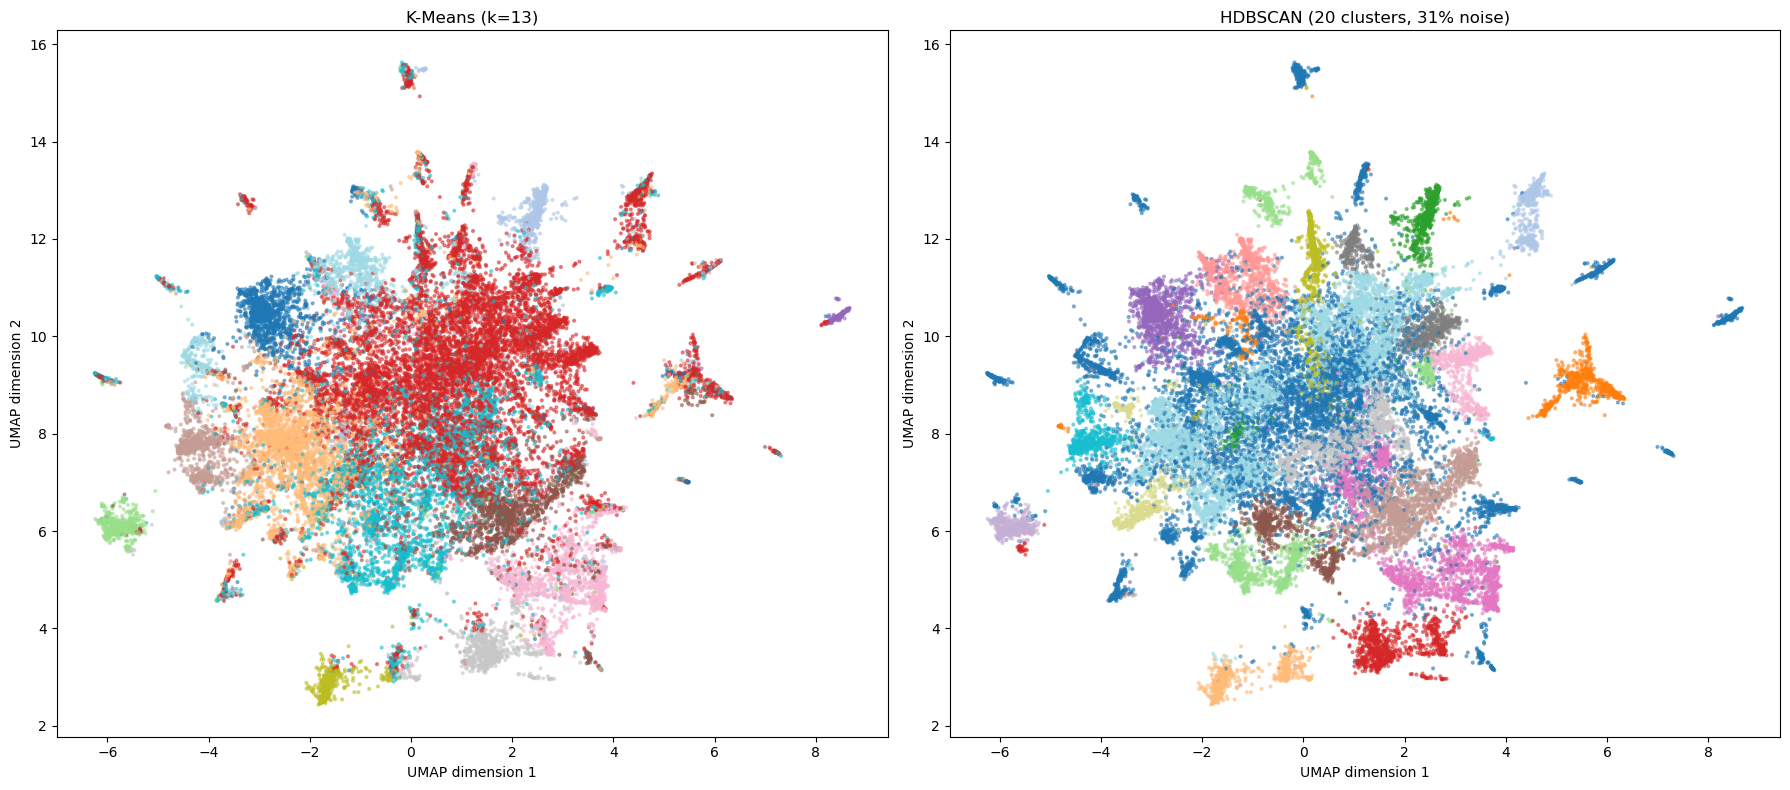

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

scatter1 = axes[0].scatter(
    umap_2d[:, 0], umap_2d[:, 1], c=kmeans_labels, cmap="tab20", s=4, alpha=0.5
)
axes[0].set_title(f"K-Means (k={K_MEANS_K})")
axes[0].set_xlabel("UMAP dimension 1")
axes[0].set_ylabel("UMAP dimension 2")

# For HDBSCAN, plot noise points in light gray, clusters in color
colors = np.where(hdbscan_labels == -1, -1, hdbscan_labels)
scatter2 = axes[1].scatter(
    umap_2d[:, 0], umap_2d[:, 1], c=colors, cmap="tab20", s=4, alpha=0.5
)
axes[1].set_title(f"HDBSCAN ({n_clusters_found} clusters, {100*n_noise/len(hdbscan_labels):.0f}% noise)")
axes[1].set_xlabel("UMAP dimension 1")
axes[1].set_ylabel("UMAP dimension 2")

plt.tight_layout()
plt.show()

Visually, the two methods diverge sharply. K-Means (on the left) splits the large, dense central mass into several arbitrarily-bounded color regions with heavy inter-mixing at the boundaries — colors bleed into each other throughout the core, showing K-Means forcing a spherical partition onto a region that has no natural spherical structure. It does correctly isolate a few of the smaller peripheral groups (e.g. the green and pink clusters at the bottom), but overall the central split looks arbitrary rather than meaningful.
HDBSCAN (on the right) shows much cleaner separation: individual color regions are visibly more contiguous and self-contained, both within the smaller satellite groups (top-right, left side) and within distinguishable sub-regions of the central mass itself. Points HDBSCAN considers noise are not forced into any color region, avoiding the artificial boundary-splitting visible on the K-Means side. This visual evidence reinforces the quantitative silhouette comparison: HDBSCAN's density-based approach better matches the actual shape of the data.


## Step 4: Choose a method and save cluster assignments for Stage 7

Based on the quantitative (silhouette) and visual comparison above, choose ONE method to carry forward for interpretation in Stage 7. Update `CHOSEN_METHOD` below (`"kmeans"` or `"hdbscan"`) and justify your choice in the markdown cell -- this decision and its justification is exactly the kind of critical assessment the case study asks for.

I am carrying forward HDBSCAN (min_cluster_size=400, min_samples=15, 20 clusters, 30.5% noise) rather than K-Means (k=13) for Stage 7 interpretation. This choice is supported by both the quantitative comparison — HDBSCAN's silhouette score (0.4547) substantially exceeds K-Means' (0.0520) — and the visual comparison, where HDBSCAN produces cleaner, more contiguous cluster boundaries that better reflect the dense-core-plus-satellite-groups structure identified back in Stage 5's UMAP visualization. K-Means' requirement to force every point into a roughly spherical cluster, including papers sitting in the large, diffuse cs.LG/cs.AI core, produces boundaries that look arbitrary rather than meaningful. HDBSCAN's 30.5% noise rate is treated as an honest reflection of genuinely ambiguous, cross-topic papers rather than a shortcoming — a limitation worth stating explicitly in the final report, since it means roughly a third of papers will not receive a specific trend classification.

In [10]:
CHOSEN_METHOD = "hdbscan"  

df["cluster_kmeans"] = kmeans_labels
df["cluster_hdbscan"] = hdbscan_labels
df["cluster_final"] = df["cluster_hdbscan"] if CHOSEN_METHOD == "hdbscan" else df["cluster_kmeans"]

df.to_parquet("../data/processed/arxiv_clustered.parquet")
joblib.dump(kmeans_final, "../data/processed/kmeans_model.joblib")
joblib.dump(clusterer, "../data/processed/hdbscan_model.joblib")

print(f"Chosen method: {CHOSEN_METHOD}")
print("Saved: arxiv_clustered.parquet (with cluster_kmeans, cluster_hdbscan, cluster_final columns)")
print("Saved: kmeans_model.joblib, hdbscan_model.joblib")

Chosen method: hdbscan
Saved: arxiv_clustered.parquet (with cluster_kmeans, cluster_hdbscan, cluster_final columns)
Saved: kmeans_model.joblib, hdbscan_model.joblib
